# Import

In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx
import numpy as np

import copy

from shapely.geometry import MultiPolygon, shape
from shapely.geometry import Polygon

import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from shapely.geometry import Point, shape
from shapely import hausdorff_distance, frechet_distance

from joblib import Parallel, delayed

# Clustering

In [2]:
cf = pd.read_excel('data\EJAtlas_dataset_V1_2024-01.xlsx', sheet_name='EJAtlas Data', skiprows=[0])

In [3]:
cf.shape

(3861, 263)

In [4]:
cf['End Date'] = pd.to_datetime(cf['End Date'], errors='coerce')

In [5]:
cf['End Date'].isnull().sum() / cf.shape[0]

0.9671069671069671

In [6]:
cf['Start Date'] = pd.to_datetime(cf['Start Date'], errors='coerce')

C:\Users\admin\AppData\Local\Temp\ipykernel_14976\4179698897.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cf['Start Date'] = pd.to_datetime(cf['Start Date'], errors='coerce')


In [7]:
cf['duration'] = cf['End Date'] - cf['Start Date']

In [8]:
cf.duration.describe()

count                              22
mean               3578 days 12:00:00
std      6105 days 13:56:01.068756800
min               -187 days +00:00:00
25%                 562 days 18:00:00
50%                1540 days 00:00:00
75%                3586 days 00:00:00
max               28272 days 00:00:00
Name: duration, dtype: object

Lets filter for  
Type: Mineral ore exploration	base
Type: Mineral processing	base
Type: Tailings from mines	base
Type: Building materials extraction (quarries, sand, gravel)	base
Type: Coal extraction and processing	base

to establish an mining data frame

In [9]:
col_int = ['Type: Uranium extraction', 
           'Type: Mineral ore exploration',
           'Type: Mineral processing',
           'Type: Tailings from mines',
           'Type: Building materials extraction (quarries, sand, gravel)',
           'Type: Coal extraction and processing',
           'Type: Mineral ore exploration'   
           ]

mask = cf[col_int].eq(1).any(axis=1)

In [10]:
cf_filtered = cf[mask]

In [11]:
cf_filtered.shape

(1026, 264)

In [12]:
cfm = cf_filtered[['Conflict Id', 'Case', 'Country', 'Lat', 'Lon', 'Start Date', 'End Date', 'duration', 
'MobilizingGroup: Indigenous groups or traditional communities',
'MobilizingForm: Lawsuits, court cases, judicial activism']]

In [13]:
cfm['Lon'] = cfm['Lon'].astype(str).str.rstrip('.')
cfm['Lat'] = cfm['Lat'].astype(str).str.rstrip('.')
cfm[['Lon', 'Lat']] = cfm[['Lon', 'Lat']].astype(float)

C:\Users\admin\AppData\Local\Temp\ipykernel_14976\2846023220.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfm['Lon'] = cfm['Lon'].astype(str).str.rstrip('.')
C:\Users\admin\AppData\Local\Temp\ipykernel_14976\2846023220.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfm['Lat'] = cfm['Lat'].astype(str).str.rstrip('.')
C:\Users\admin\AppData\Local\Temp\ipykernel_14976\2846023220.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [14]:
cg = gpd.GeoDataFrame(cfm, geometry=gpd.points_from_xy(cfm.Lon, cfm.Lat))

In [15]:
cg_end = cg[cg['End Date'].isnull()]

In [16]:
cg_end.drop(columns=['Lat', 'Lon'], inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_14976\2956245899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cg_end.drop(columns=['Lat', 'Lon'], inplace=True)


<Axes: >

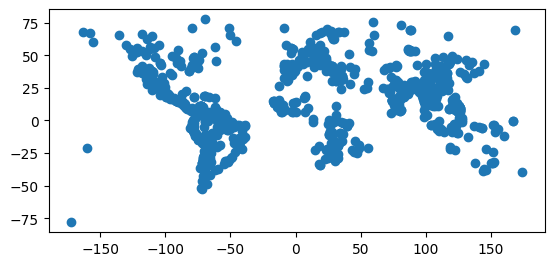

In [17]:
cg_end.plot()

In [2]:
overlays = gpd.read_file('data\interm\mine_indig_footprint_corrected.gpkg')

In [19]:
cg_end.set_crs(epsg=4326, inplace=True)

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,Conflict Id,Case,Country,Start Date,End Date,duration,MobilizingGroup: Indigenous groups or traditional communities,"MobilizingForm: Lawsuits, court cases, judicial activism",geometry
23,28,"Soda ash mining in Lake Natron, Tanzania",Tanzania,NaT,NaT,NaT,1,0,POINT (36.13565 -2.28398)
37,42,Mining of Rare Earths and Niobium in Mrima Hil...,Kenya,NaT,NaT,NaT,0,0,POINT (39.25724 -4.48231)
45,51,Mountaintop Removal Coal Mining in Laciana Val...,Spain,NaT,NaT,NaT,0,1,POINT (-6.37035 42.97363)
51,57,"Gold mining in Corcoesto, Galicia, Spain",Spain,NaT,NaT,NaT,0,0,POINT (-8.83953 43.22544)
60,67,"Opencast coal mine in Douglas Valley, Scotland...",United Kingdom,NaT,NaT,NaT,0,0,POINT (-3.82599 55.56670)
...,...,...,...,...,...,...,...,...,...
3831,6336,"Xiegou coal mine, Lvliang, Shanxi, China",China,2021-11-01,NaT,NaT,0,1,POINT (111.11440 38.65690)
3847,6371,Black Angel zinc-lead mine since 1972. Greenland,Greenland,1977-01-01,NaT,NaT,1,0,POINT (-51.27330 71.12240)
3850,6376,"Minería de Tierras Raras en Penco, Región del ...",Chile,NaT,NaT,NaT,1,0,POINT (-72.96250 -36.73500)
3853,6385,"Maniry graphite project in Ambohitsy Haut, Mad...",Madagascar,2019-01-31,NaT,NaT,1,0,POINT (44.81668 -24.49994)


In [20]:
cg_end = cg_end.to_crs(overlays.crs)

In [21]:
cg_end.set_index('Conflict Id', inplace=True)

In [22]:
cg_end

,Case,Country,Start Date,End Date,duration,MobilizingGroup: Indigenous groups or traditional communities,"MobilizingForm: Lawsuits, court cases, judicial activism",geometry
Conflict Id,,,,,,,,
28,"Soda ash mining in Lake Natron, Tanzania",Tanzania,NaT,NaT,NaT,1,0,POINT (3486594.734 -291299.574)
42,Mining of Rare Earths and Niobium in Mrima Hil...,Kenya,NaT,NaT,NaT,0,0,POINT (3787785.089 -571255.005)
51,Mountaintop Removal Coal Mining in Laciana Val...,Spain,NaT,NaT,NaT,0,1,POINT (-614651.732 4992907.210)
57,"Gold mining in Corcoesto, Galicia, Spain",Spain,NaT,NaT,NaT,0,0,POINT (-852893.460 5016510.643)
67,"Opencast coal mine in Douglas Valley, Scotland...",United Kingdom,NaT,NaT,NaT,0,0,POINT (-369155.425 6047070.890)
...,...,...,...,...,...,...,...,...
6336,"Xiegou coal mine, Lvliang, Shanxi, China",China,2021-11-01,NaT,NaT,0,1,POINT (10721015.138 4573832.904)
6371,Black Angel zinc-lead mine since 1972. Greenland,Greenland,1977-01-01,NaT,NaT,1,0,POINT (-4947169.993 6944037.247)
6376,"Minería de Tierras Raras en Penco, Región del ...",Chile,NaT,NaT,NaT,1,0,POINT (-7039880.223 -4378862.073)


In [23]:
cg_end

,Case,Country,Start Date,End Date,duration,MobilizingGroup: Indigenous groups or traditional communities,"MobilizingForm: Lawsuits, court cases, judicial activism",geometry
Conflict Id,,,,,,,,
28,"Soda ash mining in Lake Natron, Tanzania",Tanzania,NaT,NaT,NaT,1,0,POINT (3486594.734 -291299.574)
42,Mining of Rare Earths and Niobium in Mrima Hil...,Kenya,NaT,NaT,NaT,0,0,POINT (3787785.089 -571255.005)
51,Mountaintop Removal Coal Mining in Laciana Val...,Spain,NaT,NaT,NaT,0,1,POINT (-614651.732 4992907.210)
57,"Gold mining in Corcoesto, Galicia, Spain",Spain,NaT,NaT,NaT,0,0,POINT (-852893.460 5016510.643)
67,"Opencast coal mine in Douglas Valley, Scotland...",United Kingdom,NaT,NaT,NaT,0,0,POINT (-369155.425 6047070.890)
...,...,...,...,...,...,...,...,...
6336,"Xiegou coal mine, Lvliang, Shanxi, China",China,2021-11-01,NaT,NaT,0,1,POINT (10721015.138 4573832.904)
6371,Black Angel zinc-lead mine since 1972. Greenland,Greenland,1977-01-01,NaT,NaT,1,0,POINT (-4947169.993 6944037.247)
6376,"Minería de Tierras Raras en Penco, Región del ...",Chile,NaT,NaT,NaT,1,0,POINT (-7039880.223 -4378862.073)


In [24]:
cjoin = gpd.sjoin(overlays, cg_end, how='inner', op='intersects')

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [25]:
cjoin.rename(columns={'index_right': 'Conflict Id'}, inplace=True)

In [27]:
cjoin

,ID,mine_area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_buffered_area,geometry,Conflict Id,Case,Country,Start Date,End Date,duration,MobilizingGroup: Indigenous groups or traditional communities,"MobilizingForm: Lawsuits, court cases, judicial activism"
247,1819,0.690719,Argentina,ARG,"Copper,Gold",0.690719,0,0.690259,"POLYGON Z ((-7730021.767 -3589054.707 0.000, -...",743,"San Jorge threatens Uspallata, Mendoza, Argentina",Argentina,NaT,NaT,NaT,1,1
1078,7598,0.245234,China,CHN,Bauxite,0.245234,0,0.244647,"POLYGON Z ((11834238.700 2585366.674 0.000, 11...",3775,Series of pollution events by Guangxi Xinfa Al...,China,NaT,NaT,NaT,0,1
1890,13118,6.575352,Myanmar,MMR,"Iron Ore,Copper,U3O8",6.575352,0,6.556962,"POLYGON Z ((10812543.181 2310068.676 0.000, 10...",3561,"Pinpet iron mine and steel factory, Shan State...",Myanmar,NaT,NaT,NaT,1,0
2264,15098,2545.886761,Peru,PER,None,2545.886761,0,2536.175327,MULTIPOLYGON Z (((-7827776.633 -1462434.651 0....,2264,"Comunidad indigena Tres Islas, mineria ilegal,...",Peru,2009-01-01,NaT,NaT,1,1
3222,22839,22.535033,Indonesia,IDN,None,22.535033,0,22.434503,"POLYGON Z ((14186573.406 -169060.209 0.000, 14...",5827,Nickel rush threatens the health and environme...,Indonesia,2008-01-01,NaT,NaT,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83263,81237,0.440603,India,IND,None,0.440603,50,7978.072339,MULTIPOLYGON Z (((9601198.844 2497737.082 0.00...,1312,"Bhushan Power and Steel Limited, Jharkhand, India",India,2006-09-07,NaT,NaT,1,0
83264,81238,0.326466,India,IND,"Copper,U3O8,Nickel,Molybdenum",0.326466,50,7956.745519,MULTIPOLYGON Z (((9555697.828 2502074.540 0.00...,956,"Uranium Mining in Jadugoda, Jharkhand, India",India,NaT,NaT,NaT,1,0
83264,81238,0.326466,India,IND,"Copper,U3O8,Nickel,Molybdenum",0.326466,50,7956.745519,MULTIPOLYGON Z (((9555697.828 2502074.540 0.00...,1312,"Bhushan Power and Steel Limited, Jharkhand, India",India,2006-09-07,NaT,NaT,1,0
83323,81364,0.057307,Indonesia,IDN,None,0.057307,50,7895.298864,MULTIPOLYGON Z (((13593633.900 -385504.454 0.0...,5874,"Indonesia Morowali Industrial Park (IMIP), Cen...",Indonesia,2019-01-01,NaT,NaT,0,0


In [49]:
crs = 4087
cjoin.to_crs(crs, inplace=True)
cg_end.to_crs(crs, inplace=True)


def calculate_distance(row):
    polygon = shape(row.geometry)
    point = shape(cg_end.loc[row['Conflict Id'], 'geometry'])
    
    # Check if the polygon is a MultiPolygon
    if isinstance(polygon, MultiPolygon):
        hausdorff_distances = []
        frechet_distances = []
        for poly in polygon.geoms:
            hausdorff_dist = hausdorff_distance(poly, point)
            hausdorff_distances.append(hausdorff_dist)
            
            frechet_dist = frechet_distance(poly, point)
            frechet_distances.append(frechet_dist)
        
        hausdorff_dist = max(hausdorff_distances)
        frechet_dist = max(frechet_distances)
    else:
        hausdorff_dist = hausdorff_distance(polygon, point)
        frechet_dist = frechet_distance(polygon, point)
    
    return hausdorff_dist, frechet_dist

results = [calculate_distance(row) for _, row in cjoin.iterrows()]
cjoin['hausdorff_distance'], cjoin['frechet_distance'] = zip(*results)

: 

<Axes: ylabel='Frequency'>

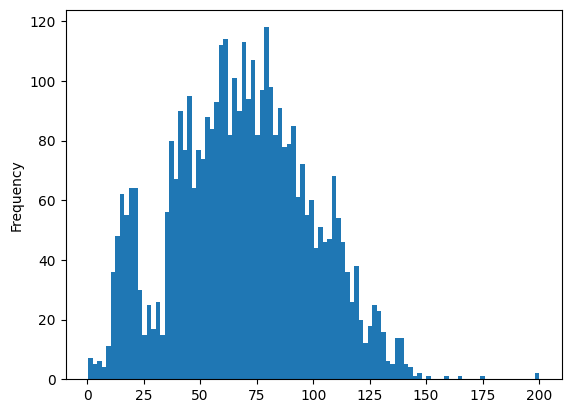

In [ ]:
cjoin['hausdorff_distance'].plot(kind='hist', bins=100)

    A smaller Hausdorff distance indicates that the conflict points and mine polygons are more similar in terms of their spatial arrangement. This means that even the most distant conflict point is relatively close to the mine polygon.
    A larger Hausdorff distance suggests a greater dissimilarity, indicating that there are parts of the conflict points that are far from the nearest mine polygon boundary.

In [ ]:
cjoin.columns

Index(['mine_area', 'admin', 'adm0_a3', 'list_of_commodities', 'overlay_area',
       'buffer', 'max_buffered_area', 'geometry', 'index_right', 'Case',
       'Country', 'Start Date', 'End Date', 'duration',
       'MobilizingGroup: Indigenous groups or traditional communities',
       'MobilizingForm: Lawsuits, court cases, judicial activism', 'distance',
       'hausdorff_distance'],
      dtype='object')

In [ ]:
cjoin.drop(columns=['distance'], inplace=True)

In [ ]:
cjoin.to_file('data\interm\mine_conflict.gpkg', driver='GPKG')

,mine_area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_buffered_area,geometry,Conflict Id,Case,Country,Start Date,End Date,duration,MobilizingGroup: Indigenous groups or traditional communities,"MobilizingForm: Lawsuits, court cases, judicial activism",hausdorff_distance
ID,,,,,,,,,,,,,,,,,
1819,0.690719,Argentina,ARG,"Copper,Gold",0.690719,0,0.690259,"POLYGON Z ((-7730021.767 -3589054.707 0.000, -...",743,"San Jorge threatens Uspallata, Mendoza, Argentina",Argentina,NaT,NaT,NaT,1,1,0.911292
7598,0.245234,China,CHN,Bauxite,0.245234,0,0.244647,"POLYGON Z ((11834238.700 2585366.674 0.000, 11...",3775,Series of pollution events by Guangxi Xinfa Al...,China,NaT,NaT,NaT,0,1,0.811573
13118,6.575352,Myanmar,MMR,"Iron Ore,Copper,U3O8",6.575352,0,6.556962,"POLYGON Z ((10812543.181 2310068.676 0.000, 10...",3561,"Pinpet iron mine and steel factory, Shan State...",Myanmar,NaT,NaT,NaT,1,0,3.042164
15098,2545.886761,Peru,PER,None,2545.886761,0,2536.175327,MULTIPOLYGON Z (((-7827776.633 -1462434.651 0....,2264,"Comunidad indigena Tres Islas, mineria ilegal,...",Peru,2009-01-01,NaT,NaT,1,1,140.592420
22839,22.535033,Indonesia,IDN,None,22.535033,0,22.434503,"POLYGON Z ((14186573.406 -169060.209 0.000, 14...",5827,Nickel rush threatens the health and environme...,Indonesia,2008-01-01,NaT,NaT,0,0,7.811365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81237,0.440603,India,IND,None,0.440603,50,7978.072339,MULTIPOLYGON Z (((9601198.844 2497737.082 0.00...,1312,"Bhushan Power and Steel Limited, Jharkhand, India",India,2006-09-07,NaT,NaT,1,0,92.472204
81238,0.326466,India,IND,"Copper,U3O8,Nickel,Molybdenum",0.326466,50,7956.745519,MULTIPOLYGON Z (((9555697.828 2502074.540 0.00...,956,"Uranium Mining in Jadugoda, Jharkhand, India",India,NaT,NaT,NaT,1,0,75.684748
81238,0.326466,India,IND,"Copper,U3O8,Nickel,Molybdenum",0.326466,50,7956.745519,MULTIPOLYGON Z (((9555697.828 2502074.540 0.00...,1312,"Bhushan Power and Steel Limited, Jharkhand, India",India,2006-09-07,NaT,NaT,1,0,71.988720
